In [9]:
# Q2
import numpy as np
np.set_printoptions(suppress=True) # wanted to get rid of the scientific notation

def gradient(x, p):
    e_x = np.exp(x)
    sum_e_x = np.sum(e_x)
    grad = p - e_x / sum_e_x
    return grad

def hessian(x):
    d = len(x)
    e_x = np.exp(x)
    sum_ex = np.sum(e_x)

    hessian_matrix = np.zeros((d,d))

    for k in range(d):
        for i in range(d):
            if i==k:
                hessian_matrix[k,k] = (-e_x[k]*sum_ex - e_x[k]**2)/(sum_ex**2)
            else:
                hessian_matrix[k, i] = (e_x[k]*e_x[i])/(sum_ex**2)

    return hessian_matrix

p = np.array([0.2, 0.3, 0.1, 0.4])
x = np.array([1,2,-1,4])

print("This is the gradient: \n", gradient(x, p))
print("\nThis is the Hessian matrix: \n", hessian(x))

This is the gradient: 
 [ 0.15822743  0.18645038  0.0943467  -0.43902451]

This is the Hessian matrix: 
 [[-0.04351752  0.00474326  0.00023615  0.03504821]
 [ 0.00474326 -0.12644314  0.00064193  0.09527091]
 [ 0.00023615  0.00064193 -0.00568526  0.00474326]
 [ 0.03504821  0.09527091  0.00474326 -1.54298663]]


Normal equation beta parameters:  [-29666.84244444    100.00021   ]
Cholesky beta parameters:  [-29666.84244444    100.00021   ]
sci-kit learn beta parameters:  [np.float64(-29666.842444444454), np.float64(100.00021000000001)]
Normal pred:  [-19166.82039444 -17666.81724444  -9666.80044444  -4666.78994444]
Cholesky pred:  [-19166.82039444 -17666.81724444  -9666.80044444  -4666.78994444]
Sklearn pred:  [-19166.82039444 -17666.81724444  -9666.80044444  -4666.78994444]


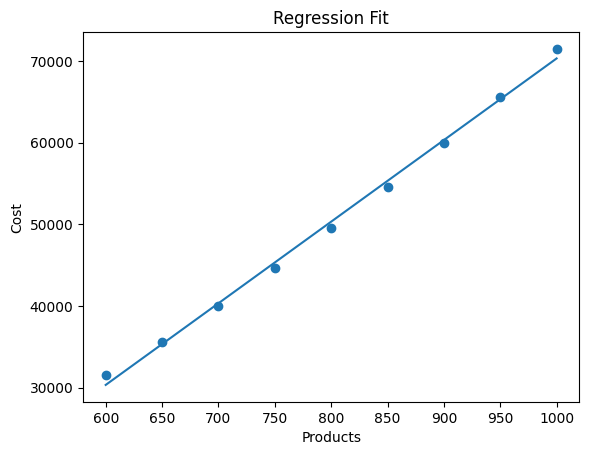

In [19]:
# Q4

# Normal Equation
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

x_hat = np.array([105,120, 200, 250])

x= np.array([600,650,700,750,800,850,900,950,1000])
y= np.array([31499.9, 35624.92, 40000.1, 44624.98, 49499.92, 54625.13, 59999.97, 65624.94, 71500.07], dtype=float)

X = np.column_stack((np.ones(len(x)), x))

XTX = X.T @ X
XTy = X.T @ y
beta_normal = np.linalg.inv(XTX) @ XTy

print("Normal equation beta parameters: ", beta_normal)

y_hat_normal = np.array([x_hat[0]*beta_normal[1] + beta_normal[0], 
                         x_hat[1]*beta_normal[1] + beta_normal[0],
                         x_hat[2]*beta_normal[1] + beta_normal[0],
                         x_hat[3]*beta_normal[1] + beta_normal[0]]
                         )


L = np.linalg.cholesky(XTX)
z = np.linalg.solve(L, XTy)

beta_cholesky = np.linalg.solve(L.T, z)
print("Cholesky beta parameters: ", beta_cholesky)


model = LinearRegression(fit_intercept=True)
model.fit(x.reshape(-1,1), y)
beta_sklearn = np.array([model.intercept_, model.coef_[0]])

print("sci-kit learn beta parameters: ", betas)

X_new = np.column_stack((np.ones(len(x_hat)), x_hat))

y_pred_normal = X_new @ beta_normal
y_pred_cholesky = X_new @ beta_cholesky
y_pred_sklearn = model.predict(x_hat.reshape(-1,1))

print("Normal pred: ", y_pred_normal)
print("Cholesky pred: ", y_pred_cholesky)
print("Sklearn pred: ", y_pred_sklearn)

plt.figure()
plt.scatter(x, y)
x_line = np.linspace(min(x), max(x), 100)
y_line = beta_normal[0] + beta_normal[1] * x_line
plt.plot(x_line, y_line)
plt.xlabel("Products")
plt.ylabel("Cost")
plt.title("Regression Fit")
plt.show()



In [27]:
# Q5c

import numpy as np
np.set_printoptions(suppress=True)

n = 10
d=8
mu_x =5
sigma_x = 0.2
sigma_eps = 0.5

X = mu_x + sigma_x * np.random.randn(n, d)

X_design = np.column_stack([np.ones(n), X])

betas = np.array([1] + [j + 1 for j in range(1, d+1)])

noise = sigma_eps * np.random.randn(n)

y = X_design @ betas + noise

def weighted_solver(X, y, w):
    W = np.diag(w)
    XTW = X.T @ W
    A = XTW @ X
    b = XTW @ y
    return np.linalg.solve(A, b)


case1 = np.ones(n)
beta_case1 = weighted_solver(X_design, y, case1)

case2 = np.random.rand(n)
beta_case2 = weighted_solver(X_design, y, case2)

print("Case 1 Solution: ", beta_case1)

print("\nCase 2 solution: ", beta_case2)


Case 1 Solution:  [28.11427005  0.93146806  2.72894981  3.20178763  6.90497385  3.63225041
  6.59889295  7.26426996  7.26023684]

Case 2 solution:  [29.38467827  1.93632286  3.44444522  2.18763631  6.4004709   4.4900294
  6.01665584  7.30659822  6.5299762 ]
